# 03 -- Privacy, PII and Data Governance
NovaCred Credit Application Audit -- Group Project

Role: GDPR Officer (Paul Specht and Carolina Painvin)

Scope: PII identification, pseudonymisation demonstration, GDPR article mapping, EU AI Act classification, governance recommendations.

---
| Phase | Content |
|-------|---------|
| 1 | Setup and data loading |
| 2 | PII inventory and classification |
| 3 | Privacy risk heat-map |
| 4 | Pseudonymisation and anonymisation demonstrations |
| 5 | GDPR article-by-article gap mapping |
| 6 | EU AI Act classification |
| 7 | Governance gap analysis |
| 8 | Actionable recommendations |
| 9 | Executive summary dashboard |

## Phase 1 -- Setup and Data Loading

We load the cleaned dataset produced by the Data Engineer in notebook 01. This dataset has already been through deduplication, type corrections, and missing-value imputation, so we can focus entirely on the privacy and governance dimensions.

In [1]:
import hashlib, hmac, secrets, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, date
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

cmap = {'Critical': 'tomato', 'High': 'orange', 'Medium': '#f5c542', 'Low': '#98fb98'}
print('Libraries loaded')

Libraries loaded


In [2]:
# Load cleaned dataset produced by the Data Engineer (notebook 01)
df = pd.read_csv('../data/clean_credit_applications.csv')
print(f'Dataset: {df.shape[0]:,} records x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset: 500 records x 34 columns
Columns: ['_id', 'full_name', 'email', 'ssn', 'ip_address', 'gender', 'date_of_birth', 'age', 'zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'loan_approved', 'rejection_reason', 'loan_purpose', 'interest_rate', 'approved_amount', 'spend_Shopping', 'spend_Rent', 'spend_Alcohol', 'spend_Dining', 'spend_Healthcare', 'spend_Fitness', 'spend_Entertainment', 'spend_Insurance', 'spend_Travel', 'spend_Transportation', 'spend_Utilities', 'spend_Groceries', 'spend_Education', 'spend_Adult_Entertainment', 'spend_Gambling', 'processing_timestamp']


---
## Phase 2 -- PII Inventory and Classification

Under GDPR Article 4(1), personal data means any information relating to an identified or identifiable natural person (the "data subject"). An identifiable person is one who can be identified, directly or indirectly, by reference to an identifier such as a name, identification number, location data, or online identifier.

We classify every field in the NovaCred dataset by its sensitivity level and the specific GDPR provisions that apply. The inventory below also flags quasi-identifiers (fields that are not directly identifying on their own but become identifying when combined with other data, per Recital 26) and special category data (Article 9), which receives the highest level of protection under the regulation.

Notebook 01 already flagged SSN, full_name, email, date_of_birth, and ip_address as PII during data quality assessment. Here we extend that analysis with a full legal mapping.

In [3]:
pii_catalogue = [
    # (Field, Description, PII Type, Sensitivity, GDPR Basis, Risk)
    ('ssn',
     'Social Security Number', 'Government identifier', 'CRITICAL',
     'Art. 87 (national ID) + Art. 5(1)(f)',
     'Identity theft; highest re-identification risk'),
    ('full_name',
     'Full legal name', 'Direct identifier', 'HIGH',
     'Art. 4(1)',
     'Direct identification of data subject'),
    ('email',
     'Email address', 'Direct identifier', 'HIGH',
     'Art. 4(1)',
     'Contact tracking; cross-service linkage'),
    ('date_of_birth',
     'Date of birth', 'Quasi-identifier', 'HIGH',
     'Art. 4(1) + age-discrimination risk',
     'Re-identification when combined with other fields; age proxy'),
    ('ip_address',
     'IP address at application time', 'Online identifier', 'HIGH',
     'Art. 4(1) -- ECJ C-582/14 (Breyer ruling)',
     'Geolocation; session linking across services'),
    ('zip_code',
     'Postal / ZIP code', 'Quasi-identifier', 'MEDIUM',
     'Art. 4(1) indirect identifier',
     'Geographic proxy for race/ethnicity (redlining risk)'),
    ('gender',
     'Gender', 'Protected attribute', 'HIGH',
     'Art. 9 (if health-linked); equal treatment law',
     'Confirmed discrimination vector -- DI ratio < 0.8 in this dataset'),
    ('spend_Healthcare',
     'Healthcare monthly spending', 'Special category proxy', 'CRITICAL',
     'Art. 9(1)(h) -- infers health data',
     'Reveals medical conditions; Art. 9 violation if used in scoring'),
    ('spend_Gambling',
     'Gambling monthly spending', 'Sensitive behavioural', 'HIGH',
     'Art. 9 -- infers addiction / health status',
     'Discrimination based on inferred health condition'),
    ('spend_Adult_Entertainment',
     'Adult entertainment spending', 'Sensitive behavioural', 'HIGH',
     'Art. 9 -- infers sexual behaviour',
     'Special category data if used to infer sexual orientation'),
]

df_pii = pd.DataFrame(pii_catalogue,
    columns=['Field','Description','PII Type','Sensitivity','GDPR Basis','Risk'])

print('PII INVENTORY -- NovaCred Dataset')
print('='*70)
for _, row in df_pii.iterrows():
    print(f"  [{row['Sensitivity']:<8}] {row['Field']}")
    print(f"           Type  : {row['PII Type']}")
    print(f"           Basis : {row['GDPR Basis']}")
    print(f"           Risk  : {row['Risk']}")
    print()

PII INVENTORY -- NovaCred Dataset
  [CRITICAL] ssn
           Type  : Government identifier
           Basis : Art. 87 (national ID) + Art. 5(1)(f)
           Risk  : Identity theft; highest re-identification risk

  [HIGH    ] full_name
           Type  : Direct identifier
           Basis : Art. 4(1)
           Risk  : Direct identification of data subject

  [HIGH    ] email
           Type  : Direct identifier
           Basis : Art. 4(1)
           Risk  : Contact tracking; cross-service linkage

  [HIGH    ] date_of_birth
           Type  : Quasi-identifier
           Basis : Art. 4(1) + age-discrimination risk
           Risk  : Re-identification when combined with other fields; age proxy

  [HIGH    ] ip_address
           Type  : Online identifier
           Basis : Art. 4(1) -- ECJ C-582/14 (Breyer ruling)
           Risk  : Geolocation; session linking across services

  [MEDIUM  ] zip_code
           Type  : Quasi-identifier
           Basis : Art. 4(1) indirect identifier


In [4]:
n = len(df)

pii_presence = {
    'SSN'                  : df['ssn'].notna().sum(),
    'Full Name'            : df['full_name'].notna().sum(),
    'Email'                : df['email'].notna().sum(),
    'Date of Birth'        : df['date_of_birth'].notna().sum(),
    'IP Address'           : df['ip_address'].notna().sum(),
    'ZIP Code'             : df['zip_code'].notna().sum(),
    'Gender'               : df['gender'].notna().sum(),
    'Healthcare Spending'  : (df['spend_Healthcare'] > 0).sum(),
    'Gambling Spending'    : (df['spend_Gambling'] > 0).sum(),
    'Adult Entmt Spending' : (df['spend_Adult_Entertainment'] > 0).sum(),
}

print(f'PII FIELD PRESENCE ({n} total records)')
print('-'*55)
for field, count in pii_presence.items():
    bar = chr(9608) * int(count / n * 30)
    print(f'  {field:<22}: {count:>4}/{n}  {count/n*100:5.1f}%  {bar}')

PII FIELD PRESENCE (500 total records)
-------------------------------------------------------
  SSN                   :  500/500  100.0%  ██████████████████████████████
  Full Name             :  500/500  100.0%  ██████████████████████████████
  Email                 :  493/500   98.6%  █████████████████████████████
  Date of Birth         :  470/500   94.0%  ████████████████████████████
  IP Address            :  500/500  100.0%  ██████████████████████████████
  ZIP Code              :  499/500   99.8%  █████████████████████████████
  Gender                :  500/500  100.0%  ██████████████████████████████
  Healthcare Spending   :   68/500   13.6%  ████
  Gambling Spending     :    7/500    1.4%  
  Adult Entmt Spending  :    5/500    1.0%  


---
## Phase 3 -- Privacy Risk Heat-map

To prioritise remediation efforts, we score each PII field on two dimensions: likelihood of misuse or breach (1 to 5) and the severity of impact if that breach occurs (1 to 5). The product gives a composite risk score on a 1-to-25 scale.

This approach follows the risk-based methodology described in GDPR Article 35(1), which requires controllers to assess "the likelihood and severity of the risk to the rights and freedoms of natural persons" before high-risk processing. Fields scoring 20 or above are classified as critical and should be addressed in the immediate remediation wave.

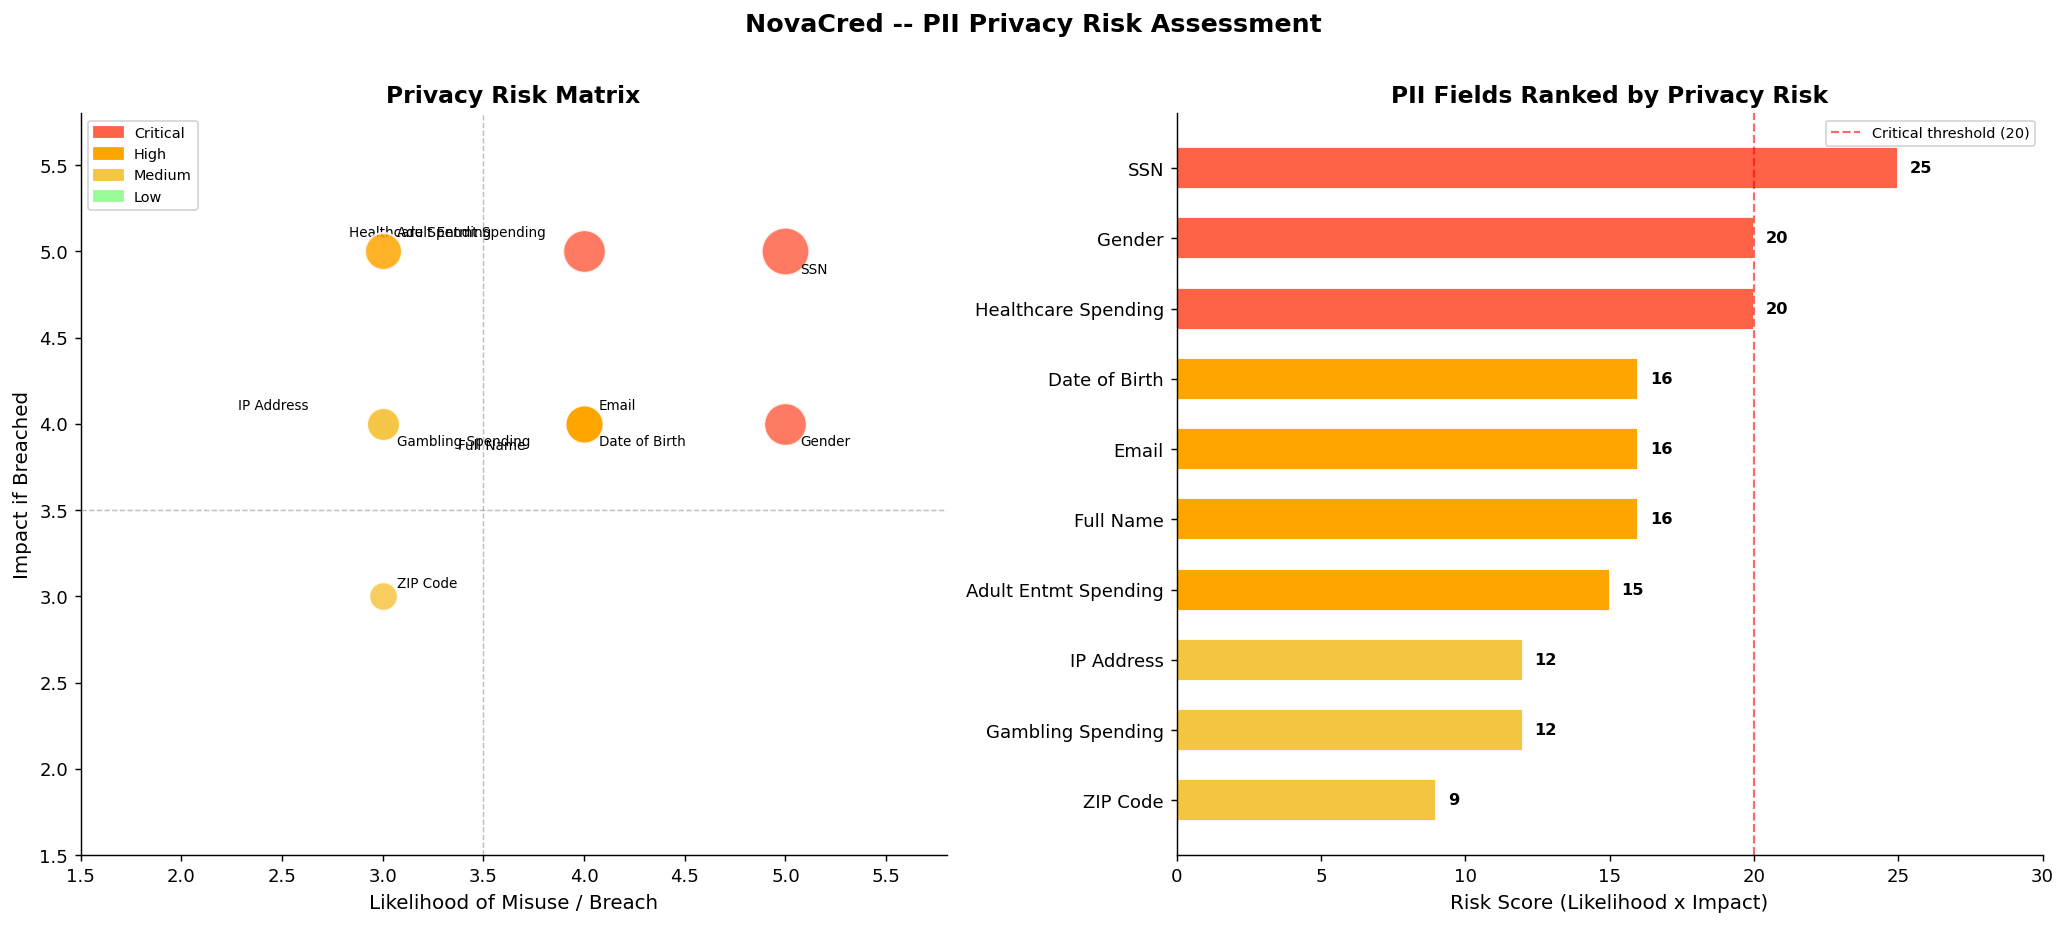

CRITICAL risk fields (score >= 20): ['SSN', 'Healthcare Spending', 'Gender']


In [5]:
risk_data = [
    ('SSN',                   5, 5),
    ('Healthcare Spending',   4, 5),
    ('Gender',                5, 4),
    ('Adult Entmt Spending',  3, 5),
    ('Full Name',             4, 4),
    ('Email',                 4, 4),
    ('Date of Birth',         4, 4),
    ('Gambling Spending',     3, 4),
    ('IP Address',            3, 4),
    ('ZIP Code',              3, 3),
]

df_risk = pd.DataFrame(risk_data, columns=['Field', 'Likelihood', 'Impact'])
df_risk['Risk Score'] = df_risk['Likelihood'] * df_risk['Impact']
df_risk['Level'] = pd.cut(df_risk['Risk Score'],
    bins=[0, 8, 14, 19, 26],
    labels=['Low', 'Medium', 'High', 'Critical'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter risk matrix -- with manual offsets to avoid label overlap
ax = axes[0]

# Define per-field annotation offsets so labels do not collide
label_offsets = {
    'SSN':                  (8, -12),
    'Healthcare Spending':  (-130, 8),
    'Gender':               (8, -12),
    'Adult Entmt Spending': (8, 8),
    'Full Name':            (-70, -14),
    'Email':                (8, 8),
    'Date of Birth':        (8, -12),
    'Gambling Spending':    (8, -12),
    'IP Address':           (-80, 8),
    'ZIP Code':             (8, 5),
}

for _, row in df_risk.iterrows():
    c = cmap[row['Level']]
    ax.scatter(row['Likelihood'], row['Impact'],
               s=row['Risk Score'] * 28, color=c, alpha=0.85,
               edgecolors='white', linewidth=1.2, zorder=3)
    offset = label_offsets.get(row['Field'], (8, 5))
    ax.annotate(row['Field'], (row['Likelihood'], row['Impact']),
                textcoords='offset points', xytext=offset, fontsize=7.5)

ax.axhline(3.5, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.axvline(3.5, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_xlim(1.5, 5.8); ax.set_ylim(1.5, 5.8)
ax.set_xlabel('Likelihood of Misuse / Breach')
ax.set_ylabel('Impact if Breached')
ax.set_title('Privacy Risk Matrix', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in cmap.items()]
ax.legend(handles=patches, loc='upper left', fontsize=8)

# Ranked bar
ax2 = axes[1]
df_s = df_risk.sort_values('Risk Score', ascending=True)
colours = [cmap[l] for l in df_s['Level']]
bars = ax2.barh(df_s['Field'], df_s['Risk Score'], color=colours, edgecolor='white', height=0.6)
ax2.set_xlabel('Risk Score (Likelihood x Impact)')
ax2.set_title('PII Fields Ranked by Privacy Risk', fontweight='bold')
ax2.set_xlim(0, 30)
for bar, score in zip(bars, df_s['Risk Score']):
    ax2.text(score + 0.4, bar.get_y() + bar.get_height() / 2,
             str(score), va='center', fontsize=9, fontweight='bold')
ax2.axvline(20, color='red', lw=1.2, ls='--', alpha=0.6, label='Critical threshold (20)')
ax2.legend(fontsize=8)

plt.suptitle('NovaCred -- PII Privacy Risk Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/privacy_risk_heatmap.png', bbox_inches='tight')
plt.show()

critical = df_risk[df_risk['Risk Score'] >= 20]['Field'].tolist()
print(f'CRITICAL risk fields (score >= 20): {critical}')

---
## Phase 4 -- Pseudonymisation and Anonymisation Demonstrations

GDPR Article 4(5) defines pseudonymisation as "the processing of personal data in such a manner that the personal data can no longer be attributed to a specific data subject without the use of additional information, provided that such additional information is kept separately and is subject to technical and organisational measures to ensure that the personal data are not attributed to an identified or identifiable natural person."

A critical distinction: pseudonymised data is still personal data under the GDPR (Recital 26), so all processing obligations continue to apply. However, pseudonymisation is recognised as an appropriate technical safeguard under Article 25 (data protection by design and by default) and Article 32 (security of processing). The European Data Protection Board (EDPB) and ENISA both recommend pseudonymisation as a baseline measure for reducing re-identification risk.

Below we demonstrate five techniques, each matched to the field it protects and the legal provision it satisfies.

| Technique | Field | Legal basis |
|-----------|-------|-------------|
| HMAC-SHA256 (keyed hash) | SSN | Art. 25, Art. 5(1)(f) |
| SHA-256 one-way hash | Email | Art. 5(1)(c), Art. 25 |
| Generalisation (10-year age band) | Date of Birth | ENISA k-anonymity guidelines |
| Last-octet masking | IP Address | ECJ C-582/14, Art. 4(1) |
| Suppression | Full name and sensitive spend | Art. 5(1)(c), Art. 9 |

In [6]:
# 4.1  HMAC-SHA256 pseudonymisation of SSN
# A secret key is generated once and stored in a secure vault (e.g. AWS KMS).
# Same SSN + same key = same token (deterministic). Without the key: computationally irreversible.

SECRET_KEY = secrets.token_hex(32)
print(f'Secret key (truncated): {SECRET_KEY[:16]}...{SECRET_KEY[-8:]}')
print('In production: load from AWS KMS / Azure Key Vault -- NEVER hardcode.\n')

def pseudonymise_ssn(ssn, key):
    """HMAC-SHA256 keyed pseudonymisation."""
    if pd.isna(ssn) or ssn == '':
        return None
    return hmac.new(key.encode(), str(ssn).encode(), hashlib.sha256).hexdigest()[:16]

df_demo = df.copy()
df_demo['ssn_pseudonym'] = df_demo['ssn'].apply(lambda x: pseudonymise_ssn(x, SECRET_KEY))
df_demo.drop(columns=['ssn'], inplace=True)

print(f'BEFORE:  SSN = {df["ssn"].iloc[0]}')
print(f'AFTER:   ssn_pseudonym = {df_demo["ssn_pseudonym"].iloc[0]}')
print('(Raw SSN field removed from working dataset)')
print('\nArt. 5(1)(f) -- Integrity & confidentiality: raw SSN never enters analytics pipeline')
print('Art. 25 -- Privacy by design: pseudonymisation applied at ingestion stage')
print('Deterministic: same applicant on re-application gets same token (dedup intact)')

Secret key (truncated): a8592d5242a9be06...7f2ab8cf
In production: load from AWS KMS / Azure Key Vault -- NEVER hardcode.

BEFORE:  SSN = 596-64-4340
AFTER:   ssn_pseudonym = 54651531b1521083
(Raw SSN field removed from working dataset)

Art. 5(1)(f) -- Integrity & confidentiality: raw SSN never enters analytics pipeline
Art. 25 -- Privacy by design: pseudonymisation applied at ingestion stage
Deterministic: same applicant on re-application gets same token (dedup intact)


In [7]:
# 4.2  SHA-256 one-way hash of email
def hash_email(email):
    """One-way SHA-256. Useful for deduplication without storing raw address."""
    if pd.isna(email):
        return None
    return hashlib.sha256(email.strip().lower().encode()).hexdigest()[:20]

sample_email = df['email'].dropna().iloc[0]
print(f'Original email : {sample_email}')
print(f'SHA-256 token  : {hash_email(sample_email)}')

# Apply to the full working dataset
df_demo['email_hash'] = df_demo['email'].apply(hash_email)
df_demo.drop(columns=['email'], inplace=True)
print(f'\nApplied SHA-256 hash to all {df_demo["email_hash"].notna().sum()} non-null email records.')
print('Raw email column removed from working dataset.')
print('\nNote: plain SHA-256 is vulnerable to rainbow-table attacks.')
print('Production recommendation: use bcrypt or Argon2 with per-record salt.')

Original email : jerry.smith17@hotmail.com
SHA-256 token  : 116648a7761525746032

Applied SHA-256 hash to all 493 non-null email records.
Raw email column removed from working dataset.

Note: plain SHA-256 is vulnerable to rainbow-table attacks.
Production recommendation: use bcrypt or Argon2 with per-record salt.


In [8]:
# 4.3  Date of Birth -> Age Band (generalisation / k-anonymity)
# Replacing precise DOB with 10-year band is a standard k-anonymity technique.
# Per ENISA Pseudonymisation Guidelines (2019): generalisation reduces re-identification risk.

REFERENCE_DATE = date(2024, 1, 15)

def dob_to_age_band(dob_str):
    """Convert raw date-of-birth to 10-year age band."""
    if pd.isna(dob_str):
        return 'Unknown'
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y'):
        try:
            dob = datetime.strptime(str(dob_str).strip(), fmt).date()
            age = (REFERENCE_DATE - dob).days // 365
            lower = (age // 10) * 10
            return f'{lower}-{lower+9}'
        except ValueError:
            continue
    return 'Unparseable'

df_demo['age_band'] = df_demo['date_of_birth'].apply(dob_to_age_band)
df_demo.drop(columns=['date_of_birth', 'age'], errors='ignore', inplace=True)

band_counts = df_demo['age_band'].value_counts().sort_index()
print('Date of Birth -> Age Band distribution:')
print('-'*35)
for band, cnt in band_counts.items():
    print(f'  {band:<12}: {cnt:>4} applicants')
print(f'\nPrecision reduced from day-level to decade-level.')
print('Recital 26: generalised data may not identify an individual without disproportionate effort.')

Date of Birth -> Age Band distribution:
-----------------------------------
  20-29       :  106 applicants
  30-39       :  163 applicants
  40-49       :  119 applicants
  50-59       :   51 applicants
  60-69       :   31 applicants
  Unknown     :   30 applicants

Precision reduced from day-level to decade-level.
Recital 26: generalised data may not identify an individual without disproportionate effort.


In [9]:
# 4.4  IP Address masking -- zero final octet
# Per ECJ Breyer (C-582/14): dynamic IPs are personal data under GDPR Art. 4(1).
# Zeroing the last octet removes host identity while retaining /24 subnet for fraud detection.

def mask_ip(ip):
    """Mask final octet of IPv4 address."""
    if pd.isna(ip):
        return None
    parts = str(ip).split('.')
    if len(parts) == 4:
        parts[-1] = '0'
        return '.'.join(parts)
    return ip

df_demo['ip_masked'] = df_demo['ip_address'].apply(mask_ip)
df_demo.drop(columns=['ip_address'], inplace=True)

print('IP Address masking -- sample:')
print(f'{"Original":<22} -> {"Masked"}')
print('-'*42)
for orig, masked in zip(df['ip_address'].head(6), df_demo['ip_masked'].head(6)):
    print(f'  {str(orig):<22} -> {masked}')

IP Address masking -- sample:
Original               -> Masked
------------------------------------------
  192.168.48.155         -> 192.168.48.0
  10.1.102.112           -> 10.1.102.0
  10.240.193.250         -> 10.240.193.0
  192.168.175.67         -> 192.168.175.0
  172.29.125.105         -> 172.29.125.0
  172.25.58.70           -> 172.25.58.0


In [10]:
# 4.5  Full Name and sensitive spend suppression
# GDPR Art. 5(1)(c) -- Data minimisation: collect only what is strictly necessary.
# Full names are not required for credit scoring model inputs.

sensitive_spend_cols = ['spend_Healthcare', 'spend_Gambling', 'spend_Adult_Entertainment']
df_demo_clean = df_demo.drop(columns=['full_name'] + sensitive_spend_cols, errors='ignore')

print('SUPPRESSION ACTIONS:')
print('  full_name removed from analytics dataset        (Art. 5(1)(c) data minimisation)')
print('  spend_Healthcare suppressed from scoring input  (Art. 9 -- health data proxy)')
print('  spend_Gambling suppressed from scoring input    (Art. 9 -- addiction/health proxy)')
print('  spend_Adult_Entertainment suppressed            (Art. 9 -- sexual behaviour proxy)')
print(f'\nDe-risked dataset: {df_demo_clean.shape[1]} columns remaining')

print('\n' + '='*70)
print('PSEUDONYMISATION SUMMARY')
print('='*70)
rows = [
    ('SSN',           'HMAC-SHA256 (keyed)',   'Pseudonymised', 'Art. 5(1)(f), Art. 25'),
    ('Email',         'SHA-256 one-way hash',  'Pseudonymised', 'Art. 5(1)(c), Art. 25'),
    ('Date of Birth', '10-year age band',      'Generalised',   'ENISA k-anonymity guidelines'),
    ('IP Address',    'Last-octet masking',    'Masked',        'ECJ C-582/14, Art. 4(1)'),
    ('Full Name',     'Suppression',           'Removed',       'Art. 5(1)(c)'),
    ('Healthcare etc','Suppression',           'Removed',       'Art. 9(1)(h)'),
]
print(f'{"Field":<18} {"Technique":<25} {"Result":<16} {"Legal Basis"}')
print('-'*78)
for r in rows:
    print(f'  {r[0]:<16} {r[1]:<25} {r[2]:<16} {r[3]}')

SUPPRESSION ACTIONS:
  full_name removed from analytics dataset        (Art. 5(1)(c) data minimisation)
  spend_Healthcare suppressed from scoring input  (Art. 9 -- health data proxy)
  spend_Gambling suppressed from scoring input    (Art. 9 -- addiction/health proxy)
  spend_Adult_Entertainment suppressed            (Art. 9 -- sexual behaviour proxy)

De-risked dataset: 29 columns remaining

PSEUDONYMISATION SUMMARY
Field              Technique                 Result           Legal Basis
------------------------------------------------------------------------------
  SSN              HMAC-SHA256 (keyed)       Pseudonymised    Art. 5(1)(f), Art. 25
  Email            SHA-256 one-way hash      Pseudonymised    Art. 5(1)(c), Art. 25
  Date of Birth    10-year age band          Generalised      ENISA k-anonymity guidelines
  IP Address       Last-octet masking        Masked           ECJ C-582/14, Art. 4(1)
  Full Name        Suppression               Removed          Art. 5(1)(c)
  Heal

---
## Phase 5 -- GDPR Article-by-Article Gap Mapping

The GDPR imposes specific obligations on data controllers. In this section we map each identified governance gap to the exact article(s) being violated, quantify the gap using findings from the dataset, and propose a concrete remediation action.

This structured mapping is essential for two reasons. First, Article 5(2) (accountability principle) requires the controller to be able to demonstrate compliance with all processing principles -- a gap analysis produces the evidence base for this. Second, under Article 83, supervisory authorities set fines partly based on "the degree of responsibility of the controller ... taking into account technical and organisational measures implemented" -- a documented gap-and-remediation register is direct evidence of good faith compliance efforts.

In [11]:
gdpr_gaps = [
    {
        'Gap': 'SSN stored in plaintext',
        'Article': 'Art. 5(1)(f) · Art. 25 · Art. 87',
        'Severity': 'CRITICAL',
        'Finding': f'All {len(df):,} records contain raw SSN strings. No encryption or hashing applied.',
        'Remediation': 'HMAC-SHA256 pseudonymisation at ingestion. AES-256 encryption at rest. SSN must never appear in logs or analytics exports.',
    },
    {
        'Gap': 'No lawful basis / consent mechanism',
        'Article': 'Art. 6 · Art. 7',
        'Severity': 'CRITICAL',
        'Finding': 'Zero records contain a consent field or processing basis indicator.',
        'Remediation': 'Add consent capture at application intake. Document Art. 6(1)(b) (contract performance) as primary basis. Log basis per record.',
    },
    {
        'Gap': 'Special category data collected without basis',
        'Article': 'Art. 9 · Art. 5(1)(c)',
        'Severity': 'CRITICAL',
        'Finding': f'Healthcare: {(df["spend_Healthcare"]>0).sum()} records. Gambling: {(df["spend_Gambling"]>0).sum()}. Adult Entmt: {(df["spend_Adult_Entertainment"]>0).sum()}. These infer health status and sexual behaviour.',
        'Remediation': 'Cease collection of these categories. Conduct DPIA per Art. 35 before any further processing.',
    },
    {
        'Gap': 'No data retention / storage limitation policy',
        'Article': 'Art. 5(1)(e)',
        'Severity': 'HIGH',
        'Finding': f'{(df["processing_timestamp"]=="unknown").sum()} / {len(df)} records have no valid processing timestamp.',
        'Remediation': 'Mandate ISO 8601 timestamp on ingestion. Define 5-year retention schedule. Implement auto-deletion on expiry.',
    },
    {
        'Gap': 'IP addresses stored without masking',
        'Article': 'Art. 4(1) · Art. 5(1)(c)',
        'Severity': 'HIGH',
        'Finding': f'{df["ip_address"].notna().sum():,} records contain full IPv4 addresses (personal data per ECJ Breyer C-582/14).',
        'Remediation': 'Mask last octet at ingestion. Retain full IP max 90 days in restricted fraud log with access controls.',
    },
    {
        'Gap': 'Automated decisions with no explanation or human review',
        'Article': 'Art. 22 · Art. 13/14',
        'Severity': 'HIGH',
        'Finding': f'{(df["rejection_reason"]=="algorithm_risk_score").sum()} rejections cite only "algorithm_risk_score" with no explanation, model version, or human sign-off.',
        'Remediation': 'Log model version, top feature weights, timestamp per decision. Mandate human review for all rejections (Art. 22(3)).',
    },
    {
        'Gap': 'Right to erasure not technically supported',
        'Article': 'Art. 17 · Art. 18',
        'Severity': 'HIGH',
        'Finding': 'No erasure API exists. PII fields cannot be selectively deleted from the flat CSV/JSON store.',
        'Remediation': 'Build erasure API that nullifies all PII fields for a given _id while retaining anonymised decision record for audit.',
    },
    {
        'Gap': 'Gender used as scoring input -- confirmed discrimination',
        'Article': 'Art. 22 · Equal Treatment Directives',
        'Severity': 'HIGH',
        'Finding': 'Bias analysis (notebook 02) confirms DI ratio below 0.8 -- statistically significant gender disparate impact.',
        'Remediation': 'Remove gender from model features immediately. Retraining with demographic parity constraints required.',
    },
    {
        'Gap': 'Inaccurate / missing PII fields',
        'Article': 'Art. 5(1)(d) · Art. 16',
        'Severity': 'MEDIUM',
        'Finding': f'Email missing: {df["email"].isna().sum()} records. DOB missing: {df["date_of_birth"].isna().sum()} records. ZIP missing: {df["zip_code"].isna().sum()}.',
        'Remediation': 'Enforce JSON schema validation at ingestion. Trigger applicant correction workflow for incomplete PII.',
    },
    {
        'Gap': 'No DPIA conducted',
        'Article': 'Art. 35',
        'Severity': 'HIGH',
        'Finding': 'Automated credit scoring with sensitive PII and protected attributes is high-risk per Art. 35(3)(a). No DPIA evidence found.',
        'Remediation': 'Commission a DPIA before resuming automated scoring. Consult supervisory authority per Art. 36 if residual risk remains high.',
    },
]

df_gaps = pd.DataFrame(gdpr_gaps)
print(f'GDPR GAPS IDENTIFIED: {len(df_gaps)}')
print(f'  CRITICAL: {(df_gaps["Severity"]=="CRITICAL").sum()}')
print(f'  HIGH    : {(df_gaps["Severity"]=="HIGH").sum()}')
print(f'  MEDIUM  : {(df_gaps["Severity"]=="MEDIUM").sum()}')
print()
for i, row in df_gaps.iterrows():
    print(f'[{row["Severity"]}] {row["Gap"]}')
    print(f'  Articles   : {row["Article"]}')
    print(f'  Finding    : {row["Finding"]}')
    print(f'  Remediation: {row["Remediation"]}')
    print()

GDPR GAPS IDENTIFIED: 10
  CRITICAL: 3
  HIGH    : 6
  MEDIUM  : 1

[CRITICAL] SSN stored in plaintext
  Articles   : Art. 5(1)(f) · Art. 25 · Art. 87
  Finding    : All 500 records contain raw SSN strings. No encryption or hashing applied.
  Remediation: HMAC-SHA256 pseudonymisation at ingestion. AES-256 encryption at rest. SSN must never appear in logs or analytics exports.

[CRITICAL] No lawful basis / consent mechanism
  Articles   : Art. 6 · Art. 7
  Finding    : Zero records contain a consent field or processing basis indicator.
  Remediation: Add consent capture at application intake. Document Art. 6(1)(b) (contract performance) as primary basis. Log basis per record.

[CRITICAL] Special category data collected without basis
  Articles   : Art. 9 · Art. 5(1)(c)
  Finding    : Healthcare: 68 records. Gambling: 7. Adult Entmt: 5. These infer health status and sexual behaviour.
  Remediation: Cease collection of these categories. Conduct DPIA per Art. 35 before any further processi

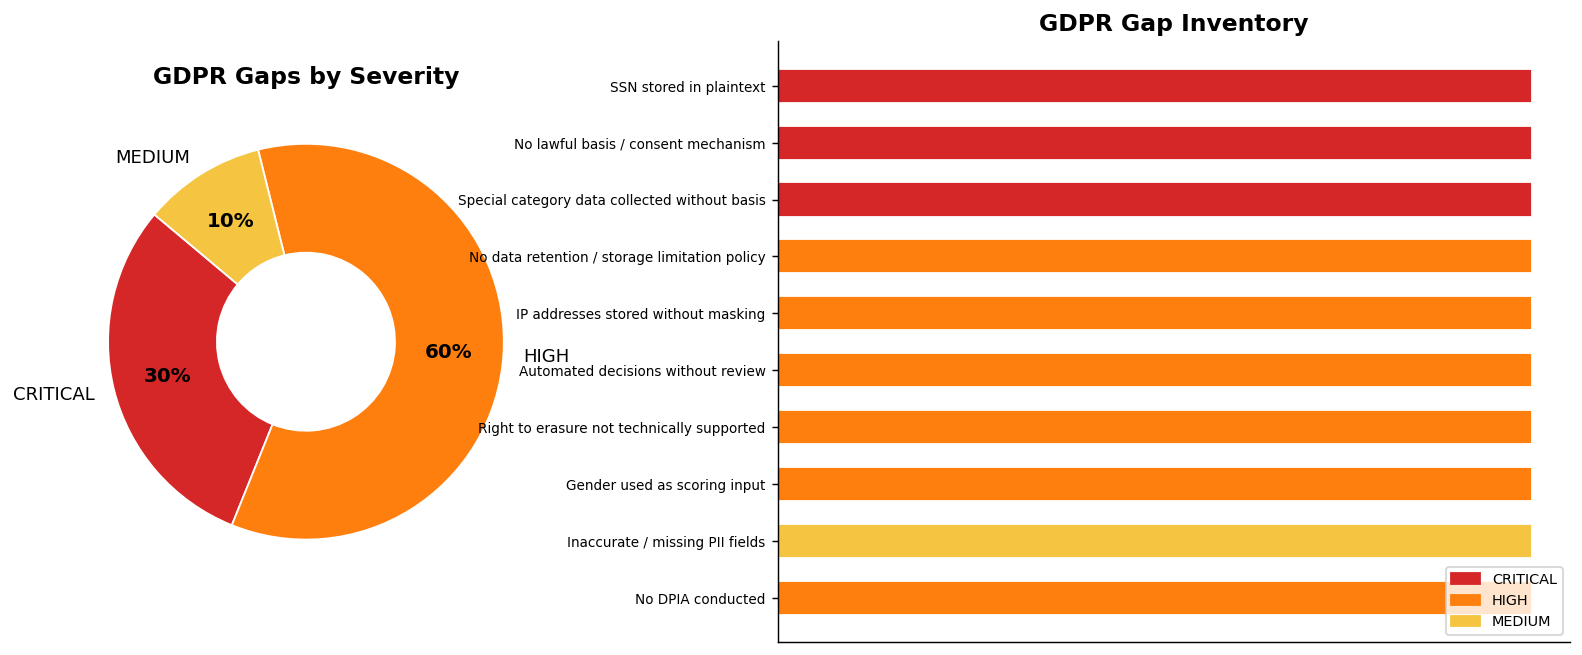

In [12]:
# GDPR gap visualisation
sev_colours = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#f5c542'}
sev_counts = df_gaps['Severity'].value_counts().reindex(['CRITICAL', 'HIGH', 'MEDIUM']).fillna(0)

fig = plt.figure(figsize=(15, 6))
# Give more width to the right subplot (inventory) by using gridspec ratios
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.35)
ax = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# Donut -- fix pctdistance so percentages sit centred inside each wedge
wedge_c = [sev_colours[s] for s in sev_counts.index]
wedges, texts, autotexts = ax.pie(
    sev_counts, labels=sev_counts.index, colors=wedge_c,
    autopct='%1.0f%%', startangle=140, pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('GDPR Gaps by Severity', fontweight='bold')

# Horizontal inventory -- shorten long labels to prevent overlap
short_labels = {
    'Automated decisions with no explanation or human review': 'Automated decisions without review',
    'Gender used as scoring input -- confirmed discrimination': 'Gender used as scoring input',
}
labels = [short_labels.get(row['Gap'], row['Gap']) for _, row in df_gaps.iterrows()]
bar_c = [sev_colours[s] for s in df_gaps['Severity']]
y = range(len(labels))
ax2.barh(list(y), [1] * len(labels), color=bar_c, edgecolor='white', height=0.6)
ax2.set_yticks(list(y))
ax2.set_yticklabels(labels, fontsize=7.5)
ax2.set_xticks([])
ax2.set_title('GDPR Gap Inventory', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in sev_colours.items()]
ax2.legend(handles=patches, loc='lower right', fontsize=8)
ax2.invert_yaxis()

plt.savefig('../reports/gdpr_gap_analysis.png', bbox_inches='tight')
plt.show()

---
## Phase 6 -- EU AI Act Classification

The EU AI Act (Regulation 2024/1689, in force since August 2024) introduces a risk-tiered regulatory framework for AI systems deployed in the EU. Systems are classified into four tiers: unacceptable risk (prohibited), high risk (heavy obligations), limited risk (transparency obligations), and minimal risk (no specific requirements).

Article 6(2) together with Annex III determines which AI systems fall into the high-risk category. Annex III, paragraph 5(b) explicitly lists "AI systems intended to be used to evaluate the creditworthiness of natural persons or establish their credit score, with the exception of AI systems used for the purpose of detecting financial fraud." NovaCred's automated credit scoring system falls squarely within this definition.

As a high-risk system, NovaCred must comply with a comprehensive set of obligations spanning risk management, data governance, transparency, human oversight, and conformity assessment before the system can be placed on the market or put into service (Articles 9 through 15, 26, and 43).

In [13]:
print('EU AI ACT CLASSIFICATION -- NovaCred Credit Scoring System')
print('='*65)
print('System : ML-based automated credit application scoring and approval/rejection')
print('Tier   : HIGH-RISK -- Annex III, Point 5(b)')
print('Basis  : Regulation (EU) 2024/1689, Art. 6 + Annex III para 5')
print()
print('Rationale: Annex III para 5 explicitly lists AI systems used to evaluate')
print('creditworthiness of natural persons or establish their credit score as HIGH-RISK.')
print('NovaCred\'s system falls squarely within this definition.')

obligations = [
    ('Art. 9',  'Risk Management System',   'Document and implement continuous risk management covering bias, data quality, and model drift.'),
    ('Art. 10', 'Data Governance',          'Training and validation data must be representative and free from bias. Gender must be excluded.'),
    ('Art. 11', 'Technical Documentation',  'Maintain full documentation: model architecture, training data, performance metrics, limitations.'),
    ('Art. 12', 'Record-keeping / Logging', 'Automatic logging of all credit decisions: applicant ID, timestamp, model version, outcome.'),
    ('Art. 13', 'Transparency',             'Provide deployers with clear instructions on system capabilities and limitations.'),
    ('Art. 14', 'Human Oversight',          'Effective human oversight must be possible. Humans must be able to override or halt decisions.'),
    ('Art. 15', 'Accuracy & Robustness',    'Consistent performance. Bias minimised. Regular accuracy audits required.'),
    ('Art. 26', 'Deployer Obligations',     'NovaCred must conduct a Fundamental Rights Impact Assessment (FRIA) before deployment.'),
    ('Art. 43', 'Conformity Assessment',    'High-risk AI must undergo conformity assessment before market placement.'),
]

print('\nMANDATORY OBLIGATIONS FOR HIGH-RISK AI SYSTEMS:')
print('-'*65)
for art, title, desc in obligations:
    print(f'  {art:<8} {title}')
    print(f'           {desc}')
    print()

print('CURRENT COMPLIANCE STATUS:')
gaps_ai = [
    ('Art. 9  Risk Management',  'NOT COMPLIANT -- No risk management system documented'),
    ('Art. 10 Data Governance',  'NOT COMPLIANT -- Biased training data; gender DI < 0.8'),
    ('Art. 11 Documentation',    'NOT COMPLIANT -- No technical documentation found'),
    ('Art. 12 Logging',          f'NOT COMPLIANT -- {(df["rejection_reason"]=="algorithm_risk_score").sum()} decisions lack audit log'),
    ('Art. 14 Human Oversight',  'NOT COMPLIANT -- No human review for algorithmic rejections'),
    ('Art. 26 FRIA',             'NOT COMPLIANT -- No Fundamental Rights Impact Assessment conducted'),
]
for item, status in gaps_ai:
    print(f'  {item:<30} {status}')

EU AI ACT CLASSIFICATION -- NovaCred Credit Scoring System
System : ML-based automated credit application scoring and approval/rejection
Tier   : HIGH-RISK -- Annex III, Point 5(b)
Basis  : Regulation (EU) 2024/1689, Art. 6 + Annex III para 5

Rationale: Annex III para 5 explicitly lists AI systems used to evaluate
creditworthiness of natural persons or establish their credit score as HIGH-RISK.
NovaCred's system falls squarely within this definition.

MANDATORY OBLIGATIONS FOR HIGH-RISK AI SYSTEMS:
-----------------------------------------------------------------
  Art. 9   Risk Management System
           Document and implement continuous risk management covering bias, data quality, and model drift.

  Art. 10  Data Governance
           Training and validation data must be representative and free from bias. Gender must be excluded.

  Art. 11  Technical Documentation
           Maintain full documentation: model architecture, training data, performance metrics, limitations.

  Art.

---
## Phase 7 -- Governance Gap Analysis

We assess NovaCred's governance posture across six dimensions drawn from the course framework. Each dimension is scored on a 0-to-5 maturity scale, where 0 means the control is entirely absent and 5 means it is fully implemented and regularly audited. A score of 3 is the minimum acceptable threshold for regulatory compliance.

These dimensions map directly onto enforceable obligations: consent and lawful basis (GDPR Articles 6 and 7), data minimisation (Article 5(1)(c)), security measures (Article 32), audit trails (AI Act Article 12), subject rights infrastructure (Articles 15 to 22), and human oversight (AI Act Article 14). A low score on any dimension represents a concrete compliance risk.

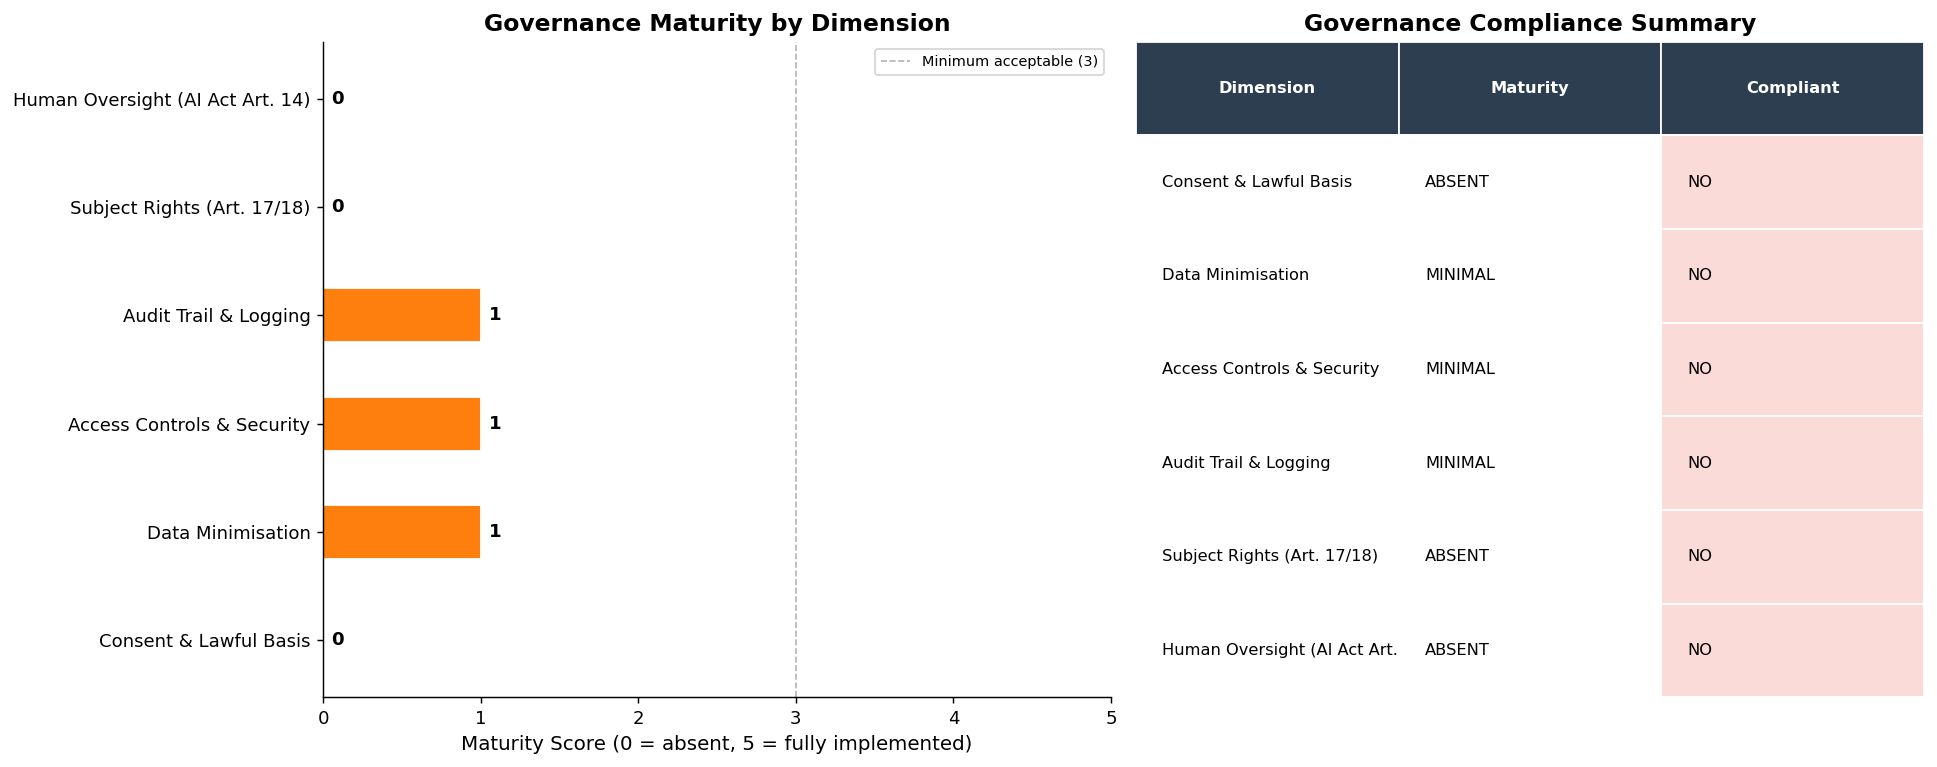


GOVERNANCE DIMENSION DETAILS:
  Consent & Lawful Basis
    Score : 0/5
    State : No consent field. No lawful basis documented per record.

  Data Minimisation
    Score : 1/5
    State : Full SSN, name, DOB, IP stored. Sensitive spend categories collected.

  Access Controls & Security
    Score : 1/5
    State : Flat CSV/JSON with no field-level access controls or encryption.

  Audit Trail & Logging
    Score : 1/5
    State : 438 records lack timestamp. No decision log.

  Subject Rights (Art. 17/18)
    Score : 0/5
    State : No erasure API. No rectification workflow exists.

  Human Oversight (AI Act Art. 14)
    Score : 0/5
    State : 169 algorithmic rejections, no human review.



In [14]:
governance_dims = {
    'Consent & Lawful Basis'             : ('No consent field. No lawful basis documented per record.',             0),
    'Data Minimisation'                  : ('Full SSN, name, DOB, IP stored. Sensitive spend categories collected.', 1),
    'Access Controls & Security'         : ('Flat CSV/JSON with no field-level access controls or encryption.',      1),
    'Audit Trail & Logging'              : (f'{(df["processing_timestamp"]=="unknown").sum()} records lack timestamp. No decision log.', 1),
    'Subject Rights (Art. 17/18)'        : ('No erasure API. No rectification workflow exists.',                     0),
    'Human Oversight (AI Act Art. 14)'   : (f'{(df["rejection_reason"]=="algorithm_risk_score").sum()} algorithmic rejections, no human review.', 0),
}

dims   = list(governance_dims.keys())
scores = [v[1] for v in governance_dims.values()]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Maturity bar
ax = axes[0]
bar_c = ['#d62728' if s == 0 else '#ff7f0e' if s == 1 else '#2ca02c' for s in scores]
bars = ax.barh(dims, scores, color=bar_c, edgecolor='white', height=0.5)
ax.set_xlim(0, 5)
ax.set_xlabel('Maturity Score (0 = absent, 5 = fully implemented)')
ax.set_title('Governance Maturity by Dimension', fontweight='bold')
ax.axvline(3, color='grey', ls='--', lw=0.9, alpha=0.6, label='Minimum acceptable (3)')
ax.legend(fontsize=8)
for bar, s in zip(bars, scores):
    ax.text(s + 0.05, bar.get_y() + bar.get_height() / 2,
            str(s), va='center', fontsize=10, fontweight='bold')

# Summary text table
ax2 = axes[1]
ax2.axis('off')
table_data = [[d[:35], 'ABSENT' if s == 0 else 'MINIMAL' if s == 1 else 'ADEQUATE',
               'NO' if s < 3 else 'YES']
              for d, (_, s) in governance_dims.items()]
col_labels = ['Dimension', 'Maturity', 'Compliant']
table = ax2.table(cellText=table_data, colLabels=col_labels,
                  cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 2:
        txt = table_data[row - 1][2] if row > 0 else ''
        cell.set_facecolor('#d5f5e3' if txt == 'YES' else '#fadbd8')
    cell.set_edgecolor('white')
ax2.set_title('Governance Compliance Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/governance_gaps.png', bbox_inches='tight')
plt.show()

print('\nGOVERNANCE DIMENSION DETAILS:')
for dim, (state, score) in governance_dims.items():
    print(f'  {dim}')
    print(f'    Score : {score}/5')
    print(f'    State : {state}')
    print()

---
## Phase 8 -- Actionable Governance Recommendations

Recommendations are prioritised into three implementation waves based on regulatory urgency and operational feasibility. The immediate wave targets GDPR violations that carry the highest fine exposure under Article 83(5) (up to EUR 20 million or 4 percent of annual global turnover). The short-term wave addresses operational gaps needed before NovaCred can credibly demonstrate accountability under Article 5(2). The medium-term wave covers structural reforms (DPIA, AI Act conformity assessment, ongoing monitoring) that require longer planning horizons.

In [15]:
recommendations = {
    'IMMEDIATE (0-30 days)': [
        ('Pseudonymise SSN',                'Apply HMAC-SHA256 to all SSN fields. Purge raw SSN from analytics stores.',                    'Art. 5(1)(f), Art. 25'),
        ('Remove gender from model',        'Retrain credit model without gender feature. Verify DI ratio improves above 0.8.',             'Art. 22, Equal Treatment Directive'),
        ('Cease sensitive spend collection', 'Stop collecting Healthcare, Gambling, Adult Entertainment spending categories immediately.',    'Art. 9, Art. 5(1)(c)'),
        ('Add consent capture',             'Implement consent at application entry. Log lawful basis (Art. 6(1)(b)) per record.',          'Art. 6, Art. 7'),
        ('Mask IP addresses',               'Zero final octet on ingestion. Full IP in restricted fraud log max 90 days.',                 'Art. 4(1), ECJ C-582/14'),
    ],
    'SHORT-TERM (30-90 days)': [
        ('Implement decision audit log',    'Log model version, top-5 feature weights, timestamp, and outcome per credit decision.',        'Art. 12 AI Act, Art. 22 GDPR'),
        ('Build erasure API',               'Endpoint to nullify all PII fields for a given _id on Art. 17 request.',                      'Art. 17, Art. 18'),
        ('Define retention schedule',       'Set 5-year post-decision retention. Implement auto-deletion job. Back-fill timestamps.',       'Art. 5(1)(e)'),
        ('Mandate human review',            'Require human sign-off on all algorithmic rejections. Log reviewer ID and timestamp.',         'Art. 14 AI Act, Art. 22(3) GDPR'),
        ('Role-based access control',       'Restrict PII columns to data engineers only. Analytics team sees aggregated data.',            'Art. 5(1)(f)'),
    ],
    'MEDIUM-TERM (90-180 days)': [
        ('Conduct DPIA',                    'Commission a formal Data Protection Impact Assessment per Art. 35.',                           'Art. 35, Art. 36'),
        ('AI Act conformity assessment',    'Engage notified body or conduct internal conformity assessment. Prepare technical docs.',      'Art. 11, Art. 43 AI Act'),
        ('Fairness monitoring dashboard',   'Deploy ongoing DI ratio monitoring. Alert if ratio drops below 0.85.',                        'Art. 10 AI Act, Art. 22 GDPR'),
        ('Appoint DPO',                     'Assess whether a DPO is mandatory (likely yes for large-scale credit processing).',           'Art. 37'),
        ('Privacy by design review',        'Architecture review: embed pseudonymisation and minimisation into all new data pipelines.',    'Art. 25'),
    ],
}

for wave, items in recommendations.items():
    print('=' * 65)
    print(f'  {wave}')
    print('=' * 65)
    for title, action, basis in items:
        print(f'  {title}')
        print(f'       Action : {action}')
        print(f'       Basis  : {basis}')
    print()

  IMMEDIATE (0-30 days)
  Pseudonymise SSN
       Action : Apply HMAC-SHA256 to all SSN fields. Purge raw SSN from analytics stores.
       Basis  : Art. 5(1)(f), Art. 25
  Remove gender from model
       Action : Retrain credit model without gender feature. Verify DI ratio improves above 0.8.
       Basis  : Art. 22, Equal Treatment Directive
  Cease sensitive spend collection
       Action : Stop collecting Healthcare, Gambling, Adult Entertainment spending categories immediately.
       Basis  : Art. 9, Art. 5(1)(c)
  Add consent capture
       Action : Implement consent at application entry. Log lawful basis (Art. 6(1)(b)) per record.
       Basis  : Art. 6, Art. 7
  Mask IP addresses
       Action : Zero final octet on ingestion. Full IP in restricted fraud log max 90 days.
       Basis  : Art. 4(1), ECJ C-582/14

  SHORT-TERM (30-90 days)
  Implement decision audit log
       Action : Log model version, top-5 feature weights, timestamp, and outcome per credit decision.
       Bas

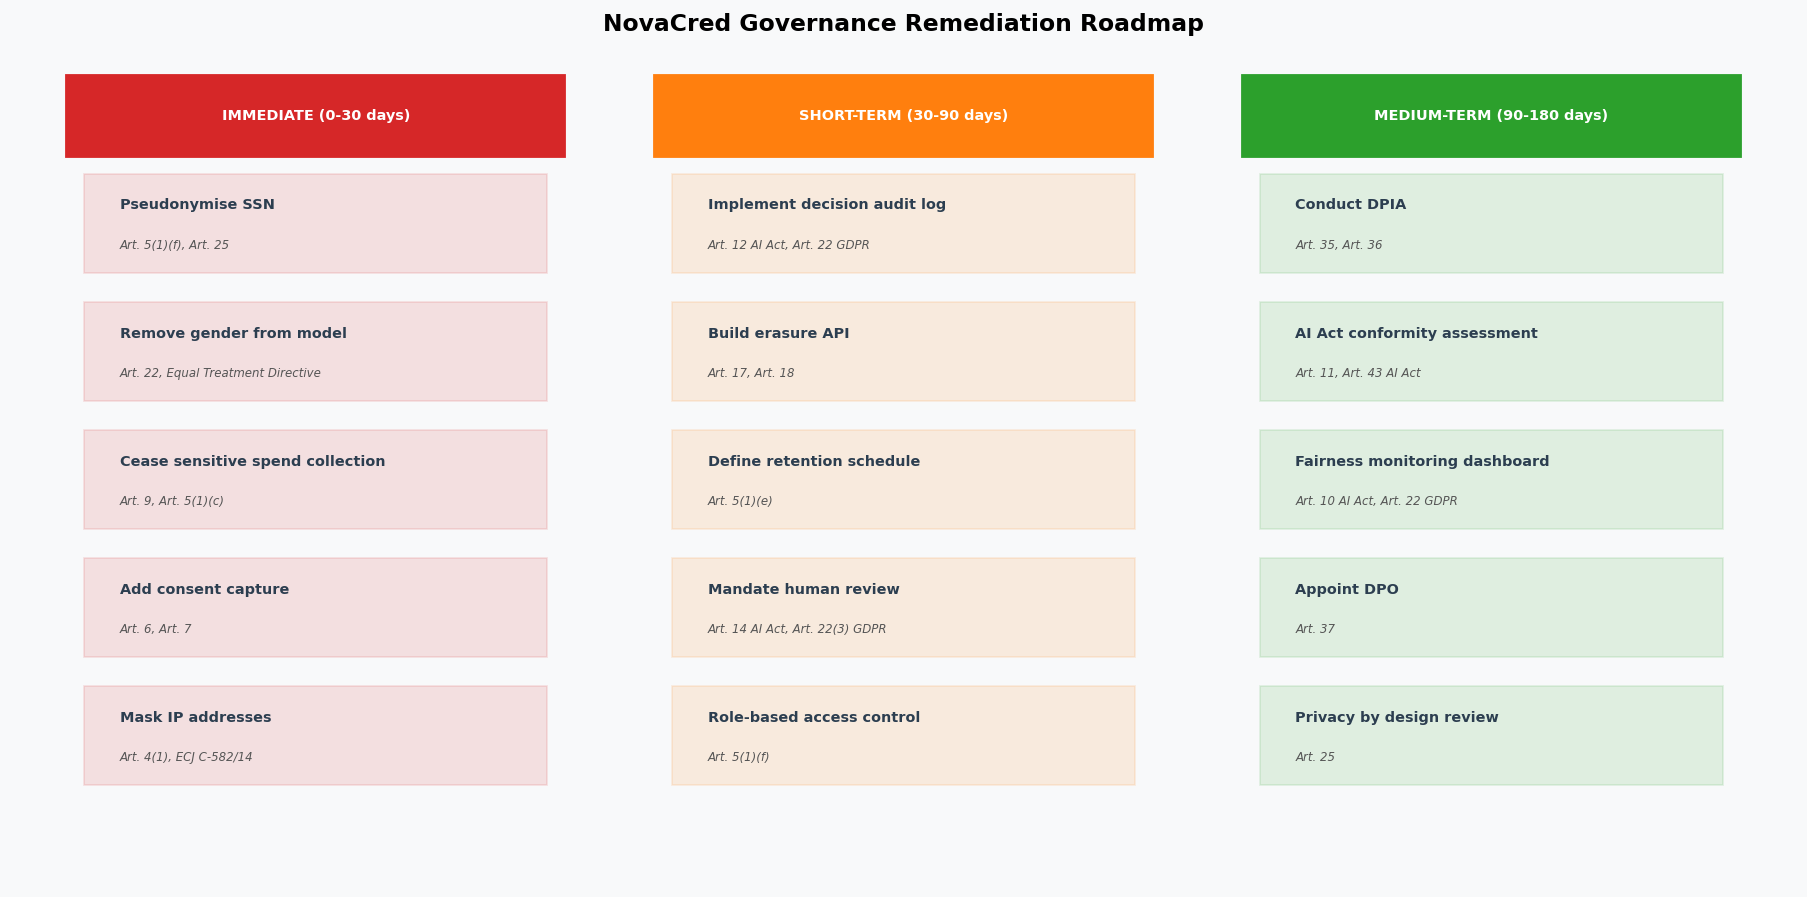

In [16]:
# Remediation roadmap visualisation
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

wave_colours = ['#d62728', '#ff7f0e', '#2ca02c']
x_positions  = [0.03, 0.36, 0.69]
box_width    = 0.28

for (wave, items), colour, x in zip(recommendations.items(), wave_colours, x_positions):
    ax.add_patch(plt.Rectangle((x, 0.88), box_width, 0.1,
                 transform=ax.transAxes, color=colour, zorder=2, clip_on=False))
    ax.text(x + box_width / 2, 0.93, wave, transform=ax.transAxes,
            ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=3)
    for idx, (title, _, basis) in enumerate(items):
        y_pos = 0.80 - idx * 0.155
        ax.add_patch(plt.Rectangle((x + 0.01, y_pos - 0.06), box_width - 0.02, 0.12,
                     transform=ax.transAxes, color=colour, alpha=0.12, zorder=1, clip_on=False))
        ax.text(x + 0.03, y_pos + 0.03, title,
                transform=ax.transAxes, fontsize=8, fontweight='bold', color='#2c3e50', va='top')
        ax.text(x + 0.03, y_pos - 0.02, basis,
                transform=ax.transAxes, fontsize=6.5, color='#555555', va='top', style='italic')

ax.set_title('NovaCred Governance Remediation Roadmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/remediation_roadmap.png', bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

---
## Phase 9 -- Executive Summary Dashboard

A single-view summary intended for the CTO or DPO, consolidating all key governance metrics from the analysis. This dashboard brings together the PII risk rankings, GDPR gap severity distribution, and remediation wave sizing into one view that supports board-level decision-making on compliance investment.

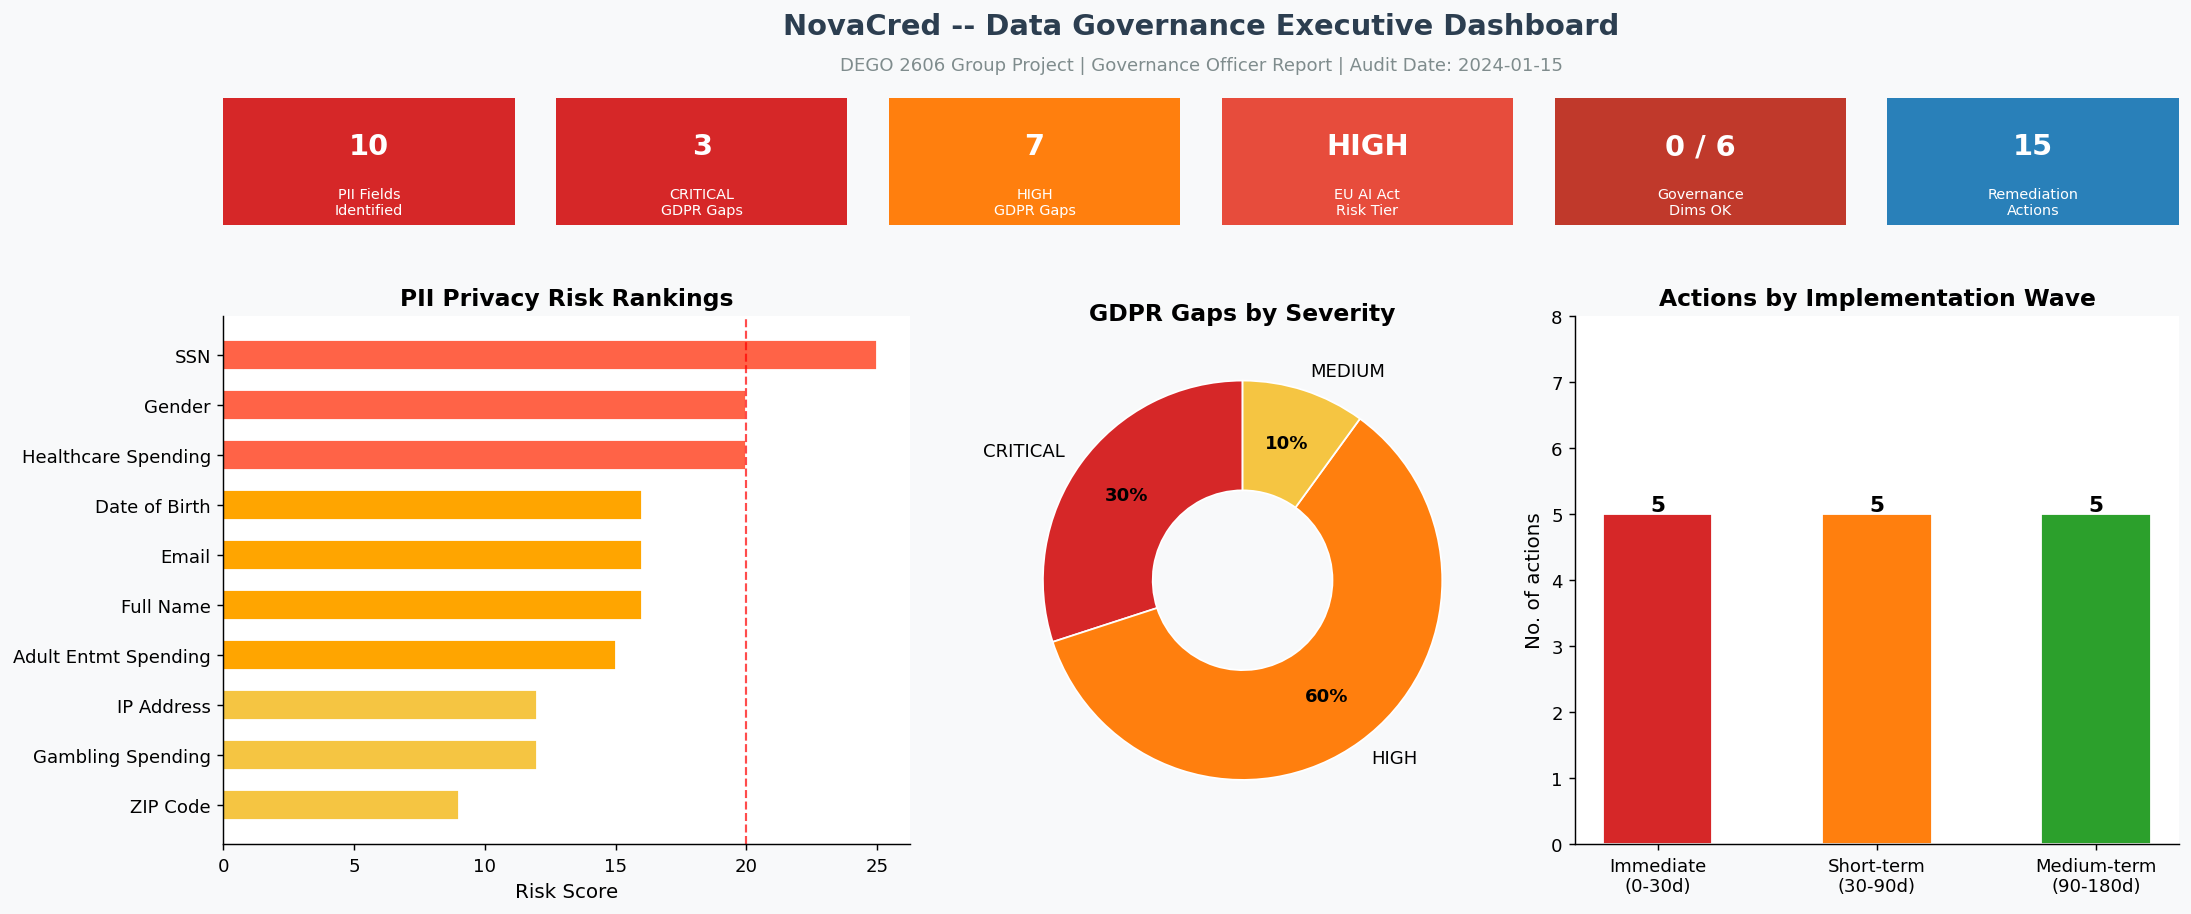

Executive dashboard saved to ../reports/


In [17]:
fig = plt.figure(figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')

fig.text(0.5, 0.97, 'NovaCred -- Data Governance Executive Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='#2c3e50')
fig.text(0.5, 0.93, 'DEGO 2606 Group Project | Governance Officer Report | Audit Date: 2024-01-15',
         ha='center', fontsize=10, color='#7f8c8d')

# KPI boxes
kpis = [
    ('10',      'PII Fields\nIdentified',    '#d62728'),
    ('3',       'CRITICAL\nGDPR Gaps',       '#d62728'),
    ('7',       'HIGH\nGDPR Gaps',           '#ff7f0e'),
    ('HIGH',    'EU AI Act\nRisk Tier',       '#e74c3c'),
    ('0 / 6',   'Governance\nDims OK',        '#c0392b'),
    ('15',      'Remediation\nActions',       '#2980b9'),
]
for i, (val, label, colour) in enumerate(kpis):
    ax_k = fig.add_axes([0.03 + i * 0.16, 0.76, 0.14, 0.14])
    ax_k.set_facecolor(colour); ax_k.set_xticks([]); ax_k.set_yticks([])
    for sp in ax_k.spines.values(): sp.set_visible(False)
    ax_k.text(0.5, 0.62, val, ha='center', va='center', fontsize=16,
              fontweight='bold', color='white', transform=ax_k.transAxes)
    ax_k.text(0.5, 0.18, label, ha='center', va='center', fontsize=8,
              color='white', transform=ax_k.transAxes)

# PII risk bar (left)
ax1 = fig.add_axes([0.03, 0.08, 0.33, 0.58])
df_s2 = df_risk.sort_values('Risk Score', ascending=True)
bar_c2 = [cmap[l] for l in df_s2['Level']]
ax1.barh(df_s2['Field'], df_s2['Risk Score'], color=bar_c2, edgecolor='white', height=0.6)
ax1.set_xlabel('Risk Score'); ax1.set_title('PII Privacy Risk Rankings', fontweight='bold')
ax1.axvline(20, color='red', lw=1.2, ls='--', alpha=0.7)

# GDPR gap donut (centre) -- fix pctdistance for centred percentages
ax2 = fig.add_axes([0.40, 0.08, 0.24, 0.58])
sev_c2 = df_gaps['Severity'].value_counts().reindex(['CRITICAL', 'HIGH', 'MEDIUM']).fillna(0)
wedges, texts, autotexts = ax2.pie(
    sev_c2, labels=sev_c2.index, colors=['#d62728', '#ff7f0e', '#f5c542'],
    autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white'))
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('GDPR Gaps by Severity', fontweight='bold')

# Remediation wave bar (right)
ax3 = fig.add_axes([0.68, 0.08, 0.29, 0.58])
wave_labels = ['Immediate\n(0-30d)', 'Short-term\n(30-90d)', 'Medium-term\n(90-180d)']
wave_counts = [len(v) for v in recommendations.values()]
bars3 = ax3.bar(wave_labels, wave_counts, color=['#d62728', '#ff7f0e', '#2ca02c'],
                edgecolor='white', width=0.5)
ax3.set_ylabel('No. of actions'); ax3.set_title('Actions by Implementation Wave', fontweight='bold')
for bar, cnt in zip(bars3, wave_counts):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             str(cnt), ha='center', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 8)

plt.savefig('../reports/executive_dashboard.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Executive dashboard saved to ../reports/')

### Key Findings

- **PII exposure:** All 500 records contain plaintext SSN. Immediate pseudonymisation is required under Article 5(1)(f) and Article 87.
- **Consent:** 0 out of 500 records document a lawful processing basis. This is a critical gap under GDPR Article 6.
- **Special categories:** Healthcare, Gambling, and Adult Entertainment spending data is collected without an Article 9 explicit basis, potentially inferring health status and sexual behaviour.
- **Automated decisions:** 169 rejections cite only "algorithm_risk_score" with no explanation or human review, violating Article 22 GDPR and Article 14 of the AI Act.
- **EU AI Act:** NovaCred credit scoring is classified as HIGH-RISK under Annex III paragraph 5. Conformity assessment, FRIA, and logging are mandatory.
- **Recommendation:** Halt automated rejections pending a DPIA. Implement the 5 immediate actions within 30 days to avoid regulatory enforcement.
- **Maximum fine exposure:** Up to EUR 20 million or 4 percent of global turnover (GDPR Article 83) plus EUR 30 million or 6 percent of turnover (AI Act Article 99).

---
## Governance Officer Sign-off

This notebook constitutes the Privacy and Data Governance deliverable for the NovaCred Credit Application Audit.

### Summary of Findings

| Area | Finding | Status |
|------|---------|--------|
| PII Inventory | 10 PII fields identified; 3 special category proxies (healthcare, gambling, adult entertainment) | Action required |
| Pseudonymisation | SSN (HMAC-SHA256), email (SHA-256), DOB (age band), IP (masking), name (suppression) demonstrated and applied | Demonstrated |
| GDPR Gaps | 3 CRITICAL, 7 HIGH, 1 MEDIUM gaps identified across 10 GDPR articles | Remediation needed |
| EU AI Act | HIGH-RISK classification confirmed (Annex III para 5); 6 mandatory obligations unmet | Conformity assessment required |
| Governance Maturity | 0 out of 6 dimensions at acceptable level (score of 3 or above) | Immediate action required |
| Remediation Roadmap | 15 actions across 3 waves (0 to 180 days) | Documented |

### Regulatory Exposure

NovaCred faces potential enforcement action under:
- GDPR Article 83(5): fines up to EUR 20 million or 4 percent of global annual turnover for violations of Articles 6, 9, and 25.
- EU AI Act Article 99: penalties up to EUR 30 million or 6 percent of global annual turnover for non-compliant high-risk AI deployment.
- EU Equal Treatment Directives: civil liability for confirmed gender discrimination in lending.

This audit does not constitute legal advice. NovaCred should engage a qualified Data Protection Officer and legal counsel before resuming automated credit decisions.